Key Findings
- Revenue shows strong variation across months, indicating seasonal demand patterns.
- A small number of products generated a significant share of total revenue.
- Top customers contributed disproportionately to total sales.
- The UK generated the highest revenue among all countries.
- A meaningful share of customers placed repeat orders, showing retention potential.

In [17]:
top_products.to_csv("../outputs/top_products.csv")
top_customers.to_csv("../outputs/top_customers.csv")
country_revenue.to_csv("../outputs/country_revenue.csv")
monthly_revenue.to_csv("../outputs/monthly_revenue.csv")

In [16]:
orders_per_customer = df.groupby("CustomerID")["InvoiceNo"].nunique()
repeat_customers = (orders_per_customer > 1).sum()
one_time_customers = (orders_per_customer == 1).sum()

print("Repeat customers: - analysis.ipynb:5", repeat_customers)
print("Onetime customers: - analysis.ipynb:6", one_time_customers)

Repeat customers: - analysis.ipynb:5 2845
Onetime customers: - analysis.ipynb:6 1493


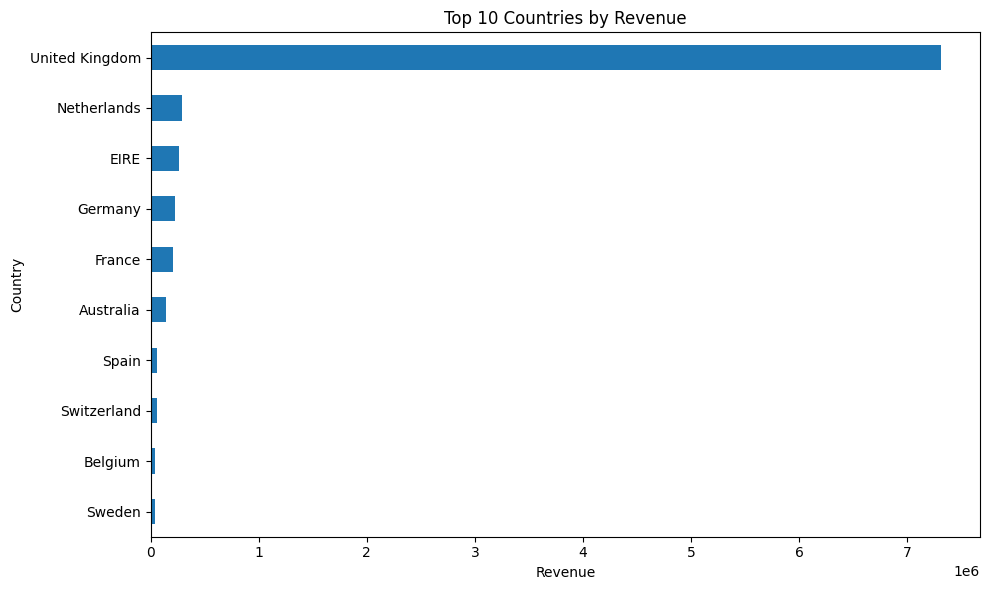

In [15]:
country_revenue.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

In [14]:
country_revenue = df.groupby("Country")["Revenue"].sum().sort_values(ascending=False).head(10)
country_revenue

Country
United Kingdom    7308391.554
Netherlands        285446.340
EIRE               265545.900
Germany            228867.140
France             209024.050
Australia          138521.310
Spain               61577.110
Switzerland         56443.950
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

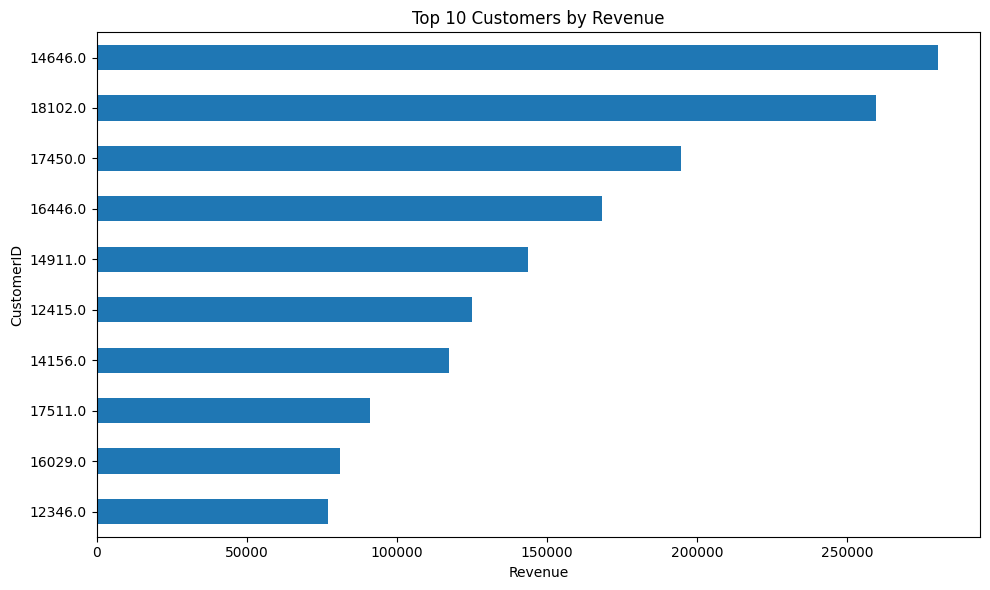

In [13]:
top_customers.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

In [12]:
top_customers = df.groupby("CustomerID")["Revenue"].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

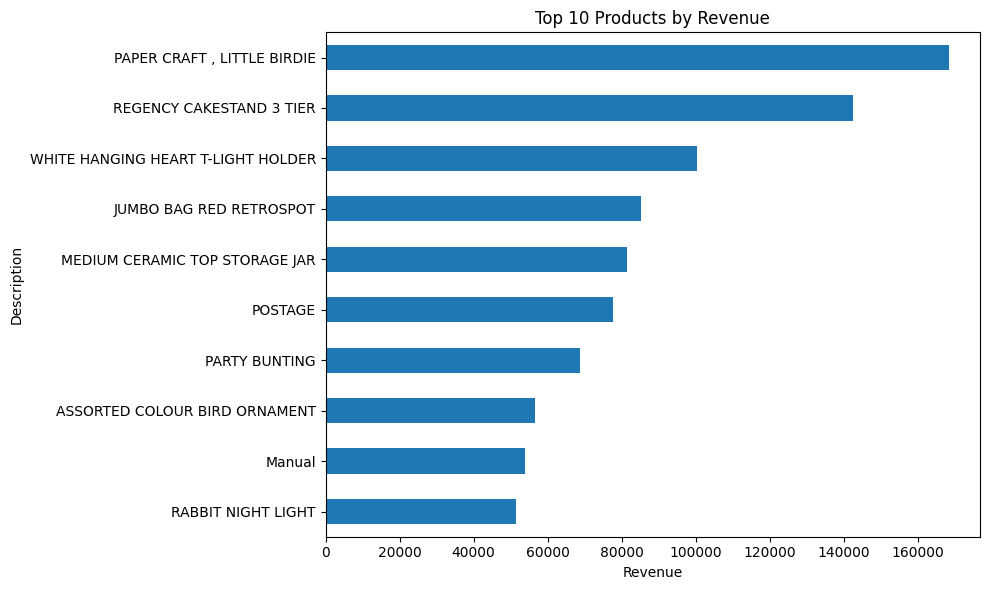

In [11]:
top_products.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.tight_layout()
plt.show()

In [10]:
top_products = df.groupby("Description")["Revenue"].sum().sort_values(ascending=False).head(10)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64

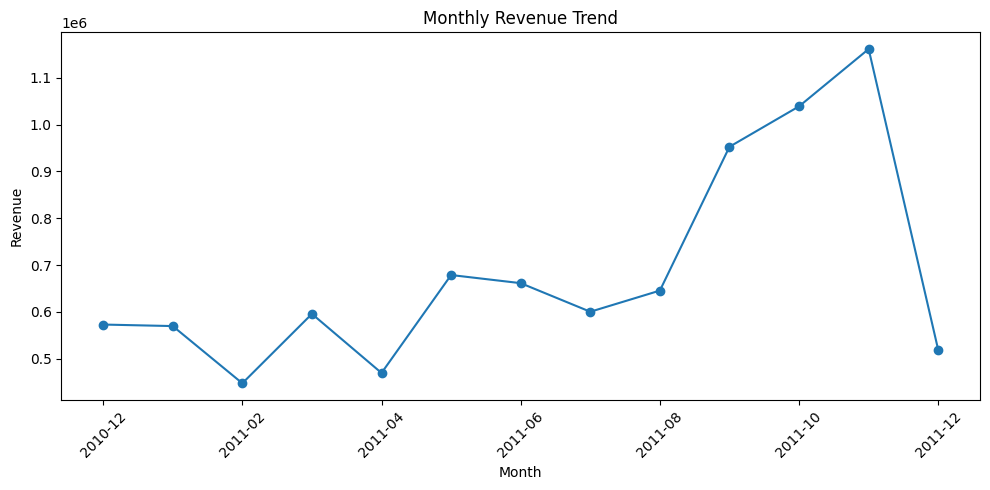

In [9]:
monthly_revenue.plot(figsize=(10,5), marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)
monthly_revenue = df.groupby("Month")["Revenue"].sum()
monthly_revenue

Month
2010-12     572713.890
2011-01     569445.040
2011-02     447137.350
2011-03     595500.760
2011-04     469200.361
2011-05     678594.560
2011-06     661213.690
2011-07     600091.011
2011-08     645343.900
2011-09     952838.382
2011-10    1039318.790
2011-11    1161817.380
2011-12     518192.790
Name: Revenue, dtype: float64

In [7]:
total_revenue = df["Revenue"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
average_order_value = total_revenue / total_orders

print("Total Revenue: - analysis.ipynb:6", round(total_revenue, 2))
print("Total Orders: - analysis.ipynb:7", total_orders)
print("Total Customers: - analysis.ipynb:8", total_customers)
print("Average Order Value: - analysis.ipynb:9", round(average_order_value, 2))

Total Revenue: - analysis.ipynb:6 8911407.9
Total Orders: - analysis.ipynb:7 18532
Total Customers: - analysis.ipynb:8 4338
Average Order Value: - analysis.ipynb:9 480.87


In [6]:
df = df.dropna(subset=["CustomerID", "Description"])
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

df["CustomerID"] = df["CustomerID"].astype(str)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [5]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [4]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 33.1 MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/online_retail.csv", encoding="ISO-8859-1")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
